### Upload Data and Create a Data Object

In [1]:
import pandas as pd
data = pd.read_csv('final_merged_data.csv')

In [2]:
def create_agreement_object(row):
    return {
        'party': row['actor_name_Node2'],
        'hi_kg_id': row['HI-KG-concept'],
        'location': row['admin2Name'],
        'geo_kg_id': row['GID'],
        'date': row['date'][:7] 
    }

agreement_objects = data.apply(create_agreement_object, axis=1).tolist()
agreement_objects

[{'party': '3R',
  'hi_kg_id': '3rArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12'},
 {'party': 'FDPC',
  'hi_kg_id': 'fdpcArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12'},
 {'party': 'FPRC',
  'hi_kg_id': 'fprcArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12'},
 {'party': 'FPRC-AK',
  'hi_kg_id': 'fprcArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12'},
 {'party': 'LRA',
  'hi_kg_id': 'lraArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12'},
 {'party': 'MLCJ',
  'hi_kg_id': 'mlcjArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12'},
 {'party': 'MNLC',
  'hi_kg_id': nan,
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12'

### Add Conflict Spells

In [4]:
data2 = pd.read_csv('CARrebeldisputes_2011_2023.csv')
data2['date_start'] = data2['date_start'].astype(str)
data2['adm_2'] = data2['adm_2'].str.replace(' region', '', regex=False).str.split().str[0]
data2

,date_start,side_a,side_b,adm_2
0,2011-09,CPJP,Seleka,Bria
1,2013-09,anti-Balaka,FPRC,Bossembélé
2,2013-09,anti-Balaka,FPRC,Bossangoa
3,2013-10,anti-Balaka,FPRC,Bangassou
4,2013-10,anti-Balaka,FPRC,Bossangoa
...,...,...,...,...
178,2023-05,Azande Ani Kpi Gbe,CPC,Obo
179,2023-06,Azande Ani Kpi Gbe,CPC,Obo
180,2023-07,Azande Ani Kpi Gbe,CPC,Obo
181,2023-08,Azande Ani Kpi Gbe,CPC,Obo


In [5]:
# Ensure they are datetime format
data2['year'] = pd.to_datetime(data2['date_start']).dt.year
data['year'] = pd.to_datetime(data['date']).dt.year  

def find_rival(party, location, year):
    """Find the rival party from data2 based on matching party, location, and year."""
    matched_events = data2[
        ((data2['side_a'] == party) | (data2['side_b'] == party)) &  # Check if the party appears in either side
        (data2['adm_2'] == location) &  # Match location
        (data2['year'] == year)  # Match the year
    ]
    
    if not matched_events.empty:
        rivals = set(matched_events['side_a']).union(set(matched_events['side_b']))
        rivals.discard(party)  # Remove the party itself from the rival list
        return ', '.join(rivals) if rivals else None  # Return as a comma-separated string if multiple rivals exist

    return None  # Return None if no rival found

def create_agreement_object(row):
    year = row['year']  # Extract year from agreement date
    rival = find_rival(row['actor_name_Node2'], row['admin2Name'], year)
    
    return {
        'party': row['actor_name_Node2'],
        'hi_kg_id': row['HI-KG-concept'],
        'location': row['admin2Name'],
        'geo_kg_id': row['GID'],
        'date': row['date'][:7], 
        'rival': rival  
    }

agreement_objects = data.apply(create_agreement_object, axis=1).tolist()
agreement_objects

[{'party': '3R',
  'hi_kg_id': '3rArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12',
  'rival': 'anti-Balaka'},
 {'party': 'FDPC',
  'hi_kg_id': 'fdpcArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12',
  'rival': None},
 {'party': 'FPRC',
  'hi_kg_id': 'fprcArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12',
  'rival': None},
 {'party': 'FPRC-AK',
  'hi_kg_id': 'fprcArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12',
  'rival': None},
 {'party': 'LRA',
  'hi_kg_id': 'lraArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12',
  'rival': None},
 {'party': 'MLCJ',
  'hi_kg_id': 'mlcjArmedNonGovernmentalOrganizedGroup',
  'location': 'Bouar',
  'geo_kg_id': 'CAF.11.3_1',
  'date': '2017-12',
  'rival': None}

### Visualization

/var/folders/xm/vzll9mj13bd05brsdt727hnc0000gn/T/ipykernel_35731/3048433081.py:102: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = bamingui.geometry.centroid.iloc[0]


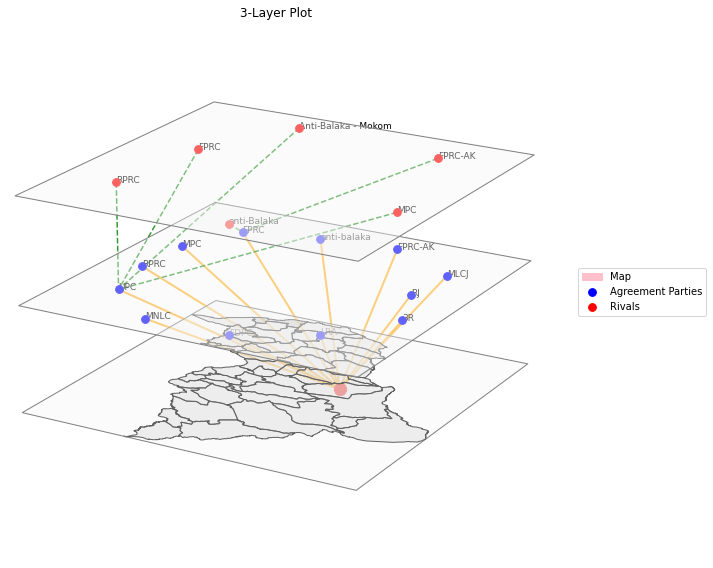

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import affinity
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.patches as mpatches  

# Load agreement_objects
df = pd.DataFrame(agreement_objects) 
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.sort_values(by=['date', 'geo_kg_id'], inplace=True)

# Filter to a specific date
df_filtered = df[df['date'] == '2017-10']

# Agreement parties 
parties = df_filtered['party'].dropna().unique()

# Rivals 
disagg_rival_map = {}    # (row_idx, chunk_idx) -> internal_label
display_label_map = {}   # internal_label -> short text for the label

for idx, row in df_filtered.iterrows():
    val = row.get('rival')
    if pd.notna(val):
        for i, chunk in enumerate(row['rival'].split(',')):
            internal_label = f"{chunk.strip()}__row{idx}__c{i}"
            display_label_map[internal_label] = chunk.strip()
            disagg_rival_map[(idx, i)] = internal_label

rival_nodes = list(display_label_map.keys())

G_parties = nx.Graph();  G_parties.add_nodes_from(parties)
G_rivals  = nx.Graph();  G_rivals.add_nodes_from(rival_nodes)

pos_parties_2d = nx.spring_layout(G_parties, seed=42, dim=2)
pos_rivals_2d  = nx.spring_layout(G_rivals,  seed=999, dim=2)

# Load the GADM shapefile for the CAR map
shp_path = "gadm41_CAF_shp/gadm41_CAF_2.shp"
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)

# Fit to [-1.2, 1.2]
minx, miny, maxx, maxy = gdf.total_bounds
scale_x = 2.4 / (maxx - minx)
scale_y = 2.4 / (maxy - miny)

gdf["geometry"] = gdf["geometry"].apply(
    lambda geom: affinity.scale(geom, xfact=scale_x, yfact=scale_y, origin=(minx, miny))
).apply(
    lambda geom: affinity.translate(geom, xoff=-minx - 1.2, yoff=-miny - 1.2)
)

# Create 3D figure with 3 layers
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Define Z-levels 
z_map     = 0     # bottom layer
z_parties = 50    # middle layer (agreement parties)
z_rivals  = 100   # top layer (rivals)

# LAYER 1: MAP at z=0
panel_verts_map = [[
    (-1.2, -1.2, z_map),
    ( 1.2, -1.2, z_map),
    ( 1.2,  1.2, z_map),
    (-1.2,  1.2, z_map)
]]
ax.add_collection3d(
    Poly3DCollection(panel_verts_map,
                     facecolors='whitesmoke',
                     edgecolors='gray',
                     alpha=0.4)
)
for geom in gdf.geometry:
    if geom.geom_type == "Polygon":
        coords = np.array(geom.exterior.coords)
        verts  = [list(zip(coords[:,0], coords[:,1], np.full(coords.shape[0], z_map)))]
        ax.add_collection3d(Poly3DCollection(
            verts, facecolor="lightgray", edgecolor="black", alpha=0.5
        ))
    elif geom.geom_type == "MultiPolygon":
        for sub in geom.geoms:
            coords = np.array(sub.exterior.coords)
            verts  = [list(zip(coords[:,0], coords[:,1], np.full(coords.shape[0], z_map)))]
            ax.add_collection3d(
                Poly3DCollection(verts,
                                 facecolor="gray",
                                 edgecolor="black",
                                 alpha=0.4)
            )

# add a dot at the centroid of Bamingui 
bamingui = gdf[gdf['NAME_2'] == 'Bamingui']
if not bamingui.empty:
    # compute centroid
    centroid = bamingui.geometry.centroid.iloc[0]
    cx, cy = centroid.x, centroid.y
    ax.scatter(cx, cy, z_map, s=150, color='red', marker='o', label='Bamingui')

# LAYER 2: AGREEMENT PARTIES at z=50
panel_verts_parties = [[
    (-1.2, -1.2, z_parties),
    ( 1.2, -1.2, z_parties),
    ( 1.2,  1.2, z_parties),
    (-1.2,  1.2, z_parties)
]]
ax.add_collection3d(
    Poly3DCollection(panel_verts_parties,
                     facecolors='whitesmoke',
                     edgecolors='gray',
                     alpha=0.4)
)
for party in parties:
    x, y = pos_parties_2d[party]
    ax.scatter(x, y, z_parties, s=60, color='blue')
    ax.text(x, y, z_parties, party, fontsize=9, color='black')

# ADD ORANGE EDGES from each party down to the Bamingui centroid
if not bamingui.empty:
    for party in parties:
        px, py = pos_parties_2d[party]
        ax.plot([px, cx], [py, cy], [z_parties, z_map],
                color='orange', linewidth=2, alpha=0.8)

# LAYER 3: RIVALS at z=100
panel_verts_rivals = [[
    (-1.2, -1.2, z_rivals),
    ( 1.2, -1.2, z_rivals),
    ( 1.2,  1.2, z_rivals),
    (-1.2,  1.2, z_rivals)
]]
ax.add_collection3d(
    Poly3DCollection(panel_verts_rivals,
                     facecolors='whitesmoke',
                     edgecolors='gray',
                     alpha=0.4)
)
for internal_label, (x, y) in pos_rivals_2d.items():
    label = display_label_map[internal_label]
    ax.scatter(x, y, z_rivals, s=60, color='red')
    ax.text(x, y, z_rivals, label, fontsize=9, color='black')

# Inter-layer edges: Rival -> Party
for idx, row in df_filtered.iterrows():
    if pd.notna(row['rival']):
        for i, chunk in enumerate(row['rival'].split(',')):
            r_internal = disagg_rival_map[(idx, i)]
            rx, ry     = pos_rivals_2d[r_internal]
            px, py     = pos_parties_2d[row['party']]
            ax.plot([rx, px],
                    [ry, py],
                    [z_rivals, z_parties],
                    color='green',
                    linestyle='--',
                    alpha=0.8)

# Legend
ax.grid(False)
ax.axis("off")
ax.set_title("3-Layer Plot")
ax.view_init(elev=20, azim=30)

parties_proxy = ax.scatter([], [], [], color='blue', s=60, label='Agreement Parties')
rivals_proxy  = ax.scatter([], [], [], color='red',  s=60, label='Rivals')
map_patch     = mpatches.Patch(color='pink',     label='Map')

ax.legend(handles=[map_patch, parties_proxy, rivals_proxy],
          loc='center left',
          bbox_to_anchor=(1.05, 0.5))

plt.tight_layout()
plt.show()